# Previsão da expansão de luzes noturnas com VIIRS e Random Forest

Este notebook é uma versão corrigida do projeto para **prever a expansão futura da área iluminada** usando imagens `.tif` de luzes noturnas mensais.

A ideia central é:

1. Ler os GeoTIFFs mensais de cada região.
2. Montar uma composição anual por **mediana** dos 12 meses.
3. Transformar cada ano em uma **máscara iluminada / não iluminada**.
4. Treinar um modelo supervisionado para prever o estado do pixel no ano seguinte.
5. Gerar o mapa futuro e calcular a expansão como:

```python
expansao_prevista = (mascara_prevista_futura == 1) & (mascara_atual == 0)
```

Assim, o projeto continua sendo de **previsão de expansão**. O Random Forest é apenas o mecanismo usado para prever o estado futuro dos pixels.


## Base teórica usada no projeto

Este notebook foi estruturado com base em dois trabalhos principais:

- **Yao et al. (2017)** — *Simulation of Urban Expansion and Farmland Loss in China by Integrating Cellular Automata and Random Forest*. O artigo usa Random Forest para aprender regras espaciais de transição e simular expansão urbana. Link: https://arxiv.org/abs/1705.05651
- **Chakraborty & Stokes (2023)** — *Adaptive Modeling of Satellite-Derived Nighttime Lights Time-Series for Tracking Urban Change Processes Using Machine Learning*. O artigo usa séries temporais de luzes noturnas para prever padrões esperados e detectar mudanças urbanas. Link: https://arxiv.org/abs/2306.08501


## 1. Instalação das bibliotecas

No Google Colab, execute a célula abaixo. Em ambiente local, talvez você já tenha tudo instalado.


In [86]:
import sys

try:
    import rasterio
    import skimage
except Exception:
    !{sys.executable} -m pip install rasterio scikit-image tqdm


## 2. Imports e configuração geral


In [87]:
from pathlib import Path
import re
import math
import xml.etree.ElementTree as ET
import unicodedata
import warnings
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from rasterio.warp import reproject, Resampling
from scipy import ndimage
from skimage.filters import threshold_otsu
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
)

try:
    from IPython.display import display
except Exception:
    display = print

warnings.filterwarnings("ignore", category=RuntimeWarning)


## 3. Caminho dos dados


In [88]:
BASE_DIR = os.getcwd()

DATA_DIR = Path(BASE_DIR, 'data', 'NTL_LITORAL_SC', 'QGIS_LITORAL', 'RASTER', 'NTL_LITORAL')

print('Pasta com dados:', DATA_DIR.resolve())


Pasta com dados: C:\Users\thomh\Desktop\Pastas\FURB\2026.1\Processamento de Imagens\processamento-de-imagens-luzes-noturnas\src\data\NTL_LITORAL_SC\QGIS_LITORAL\RASTER\NTL_LITORAL


## 4. Parâmetros do projeto

Para o protótipo, `MIN_MESES_COMPOSICAO = 1` permite testar mesmo com poucos meses. Para a versão final do trabalho, o ideal é usar pelo menos 8 ou 12 meses por ano.


In [89]:
ANOS_DISPONIVEIS = list(range(2015, 2026))
ANO_BASE_PREVISAO = 2025
ANOS_A_PREVER = 3

MIN_MESES_COMPOSICAO = 1  # para protótipo. Para relatório final, use 8 ou 12 se seus dados estiverem completos.
METODO_COMPOSICAO = 'mediana'  # 'mediana' é mais robusto a ruído mensal.

RANDOM_STATE = 42
MAX_PIXELS_POR_CLASSE = 30000
MAX_PIXELS_REGRESSAO_POR_PAR = 60000

# Limiar mínimo de probabilidade para considerar um pixel iluminado no futuro.
# Se houver validação 2024->2025, o notebook também calcula um limiar sugerido por F1.
LIMIAR_PROBABILIDADE_PADRAO = 0.50

# Limiar separado para o modelo de expansão nova.
# Normalmente deve ser menor que o limiar de estado iluminado, porque expansão nova é rara.
LIMIAR_EXPANSAO_PADRAO = 0.35

# Para previsão de expansão urbana/luzes, é comum assumir cenário acumulado:
# um pixel já iluminado no ano base permanece como área iluminada na projeção.
# Isso evita que a saída principal vire uma 'desexpansão'.
FORCAR_PERSISTENCIA_AREA_ILUMINADA = True



## 5. Inventário automático dos arquivos

Esta etapa varre a pasta, identifica região, ano e mês pelo nome do arquivo, e verifica se existe `.aux.xml` associado.


In [ ]:
ARQUIVOS_AMOSTRA = 20

def normalizar_texto(txt):
    txt = str(txt)
    txt = unicodedata.normalize('NFKD', txt)
    txt = ''.join(c for c in txt if not unicodedata.combining(c))
    txt = txt.lower()
    txt = re.sub(r'[^a-z0-9]+', '_', txt).strip('_')
    return txt


def parse_nome_arquivo(caminho):
    nome = Path(caminho).name

    # VIIRS_NTL_MedianaMensal_[regiao]_[ano]_[mes].tif
    padrao = re.compile(
        r'VIIRS_NTL_MedianaMensal_(?P<regiao>.+?)_(?P<ano>\d{4})_(?P<mes>\d{2}).*?\.tif$',
        re.IGNORECASE
    )
    m = padrao.match(nome)

    if not m:
        return None

    regiao = m.group('regiao')
    ano = int(m.group('ano'))
    mes = int(m.group('mes'))

    return {
        'regiao': regiao,
        'regiao_id': normalizar_texto(regiao),
        'ano': ano,
        'mes': mes,
    }


def caminho_aux_xml(caminho_tif):
    caminho_tif = Path(caminho_tif)
    candidato = Path(str(caminho_tif) + '.aux.xml')
    return candidato if candidato.exists() else None


def ler_stats_aux_xml(caminho_tif):
    aux = caminho_aux_xml(caminho_tif)
    if aux is None:
        return {}

    try:
        root = ET.parse(aux).getroot()
        stats = {}
        for mdi in root.findall('.//MDI'):
            chave = mdi.attrib.get('key')
            valor = mdi.text
            if chave and valor is not None:
                try:
                    stats[chave] = float(valor)
                except ValueError:
                    stats[chave] = valor
        return stats
    except Exception as e:
        print(f'Não foi possível ler {aux.name}: {e}')
        return {}


def resgatar_dados(DATA_DIR):
    registros = []
    arquivos = sorted(Path(DATA_DIR).rglob('*.tif'))

    for caminho in arquivos:
        info = parse_nome_arquivo(caminho)
        if info is None:
            continue

        stats = ler_stats_aux_xml(caminho)

        registros.append({
            **info,
            'arquivo': str(caminho),
            'tem_aux_xml': caminho_aux_xml(caminho) is not None,
            'aux_min': stats.get('STATISTICS_MINIMUM', np.nan),
            'aux_max': stats.get('STATISTICS_MAXIMUM', np.nan),
            'aux_mean': stats.get('STATISTICS_MEAN', np.nan),
            'aux_std': stats.get('STATISTICS_STDDEV', np.nan),
            'aux_valid_percent': stats.get('STATISTICS_VALID_PERCENT', np.nan),
        })

    df = pd.DataFrame(registros)
    if len(df) == 0:
        return df

    df = df.sort_values(['regiao_id', 'ano', 'mes']).reset_index(drop=True)
    return df


df_arquivos = resgatar_dados(DATA_DIR)

print(f'Mostrando {ARQUIVOS_AMOSTRA} de {len(df_arquivos)} arquivos .tif identificados.')

display(df_arquivos.head(ARQUIVOS_AMOSTRA))


Mostrando 20 de 528 arquivos .tif identificados.


,regiao,regiao_id,ano,mes,arquivo,tem_aux_xml,aux_min,aux_max,aux_mean,aux_std,aux_valid_percent
0,Blumenau,blumenau,2015,1,c:\Users\thomh\Desktop\Pastas\FURB\2026.1\Proc...,False,NaN,NaN,NaN,NaN,NaN
1,Blumenau,blumenau,2015,2,c:\Users\thomh\Desktop\Pastas\FURB\2026.1\Proc...,False,NaN,NaN,NaN,NaN,NaN
2,Blumenau,blumenau,2015,3,c:\Users\thomh\Desktop\Pastas\FURB\2026.1\Proc...,False,NaN,NaN,NaN,NaN,NaN
3,Blumenau,blumenau,2015,4,c:\Users\thomh\Desktop\Pastas\FURB\2026.1\Proc...,False,NaN,NaN,NaN,NaN,NaN
4,Blumenau,blumenau,2015,5,c:\Users\thomh\Desktop\Pastas\FURB\2026.1\Proc...,False,NaN,NaN,NaN,NaN,NaN
5,Blumenau,blumenau,2015,6,c:\Users\thomh\Desktop\Pastas\FURB\2026.1\Proc...,False,NaN,NaN,NaN,NaN,NaN
6,Blumenau,blumenau,2015,7,c:\Users\thomh\Desktop\Pastas\FURB\2026.1\Proc...,False,NaN,NaN,NaN,NaN,NaN
7,Blumenau,blumenau,2015,8,c:\Users\thomh\Desktop\Pastas\FURB\2026.1\Proc...,False,NaN,NaN,NaN,NaN,NaN
8,Blumenau,blumenau,2015,9,c:\Users\thomh\Desktop\Pastas\FURB\2026.1\Proc...,False,NaN,NaN,NaN,NaN,NaN
9,Blumenau,blumenau,2015,10,c:\Users\thomh\Desktop\Pastas\FURB\2026.1\Proc...,False,NaN,NaN,NaN,NaN,NaN


## 6. Leitura dos GeoTIFFs

In [ ]:
def ler_raster(caminho):

    with rasterio.open(Path(caminho)) as src:
        valores_pixel = src.read(1).astype(np.float32)
        informacoes_raster = src.profile.copy()
        nodata = src.nodata

    if nodata is not None:
        valores_pixel = np.where(valores_pixel == nodata, np.nan, valores_pixel)

    valores_pixel = np.where(np.isfinite(valores_pixel), valores_pixel, np.nan).astype(np.float32)
    valores_pixel = np.where(valores_pixel < 0, 0, valores_pixel).astype(np.float32)

    return valores_pixel, informacoes_raster


def arquivos_compativeis(perfil_a, perfil_b):
    campos = ['height', 'width', 'crs', 'transform']
    return all(perfil_a.get(c) == perfil_b.get(c) for c in campos)


def equiparar_arquivos(dados_pixel, informacoes_origem, informacoes_destino, resampling=Resampling.bilinear):
    if arquivos_compativeis(informacoes_origem, informacoes_destino):
        return dados_pixel.astype(np.float32)

    destino = np.full(
        (informacoes_destino['height'], informacoes_destino['width']),
        np.nan,
        dtype=np.float32
    )

    reproject(
        source=dados_pixel.astype(np.float32),
        destination=destino,
        src_transform=informacoes_origem.get('transform'),
        src_crs=informacoes_origem.get('crs'),
        dst_transform=informacoes_destino.get('transform'),
        dst_crs=informacoes_destino.get('crs'),
        src_nodata=np.nan,
        dst_nodata=np.nan,
        resampling=resampling,
    )
    return destino


def perfil_referencia_regiao(regiao_id):
    sub = df_arquivos[df_arquivos['regiao_id'] == regiao_id].sort_values(['ano', 'mes'])
    _, perfil = ler_raster(sub.iloc[0]['arquivo'])
    return perfil


def nome_regiao(regiao_id):
    sub = df_arquivos[df_arquivos['regiao_id'] == regiao_id]
    return sub.iloc[0]['regiao']


## 7. Visualizar imagem exemplo


Exemplo: VIIRS_NTL_MedianaMensal_Blumenau_2015_01_reprojetada.tif
Shape: (185, 101)
Mínimo: 0.11768439 Máximo: 17899.691 Média: 16.565205


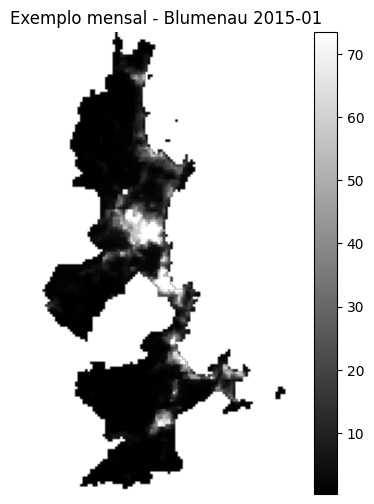

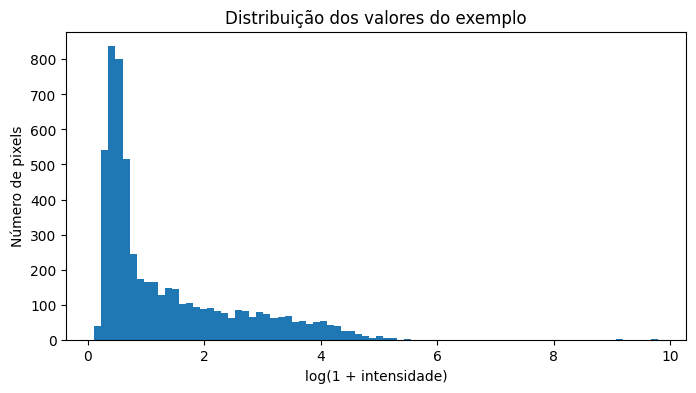

In [ ]:
def mostrar_raster(arr, titulo='', percentil_min=2, percentil_max=98, cmap='gray', figsize=(7, 6)):
    valido = arr[np.isfinite(arr)]
    vmin, vmax = np.nanpercentile(valido, [percentil_min, percentil_max])

    plt.figure(figsize=figsize)
    plt.imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax)
    plt.title(titulo)
    plt.axis('off')
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.show()


def histograma_raster(arr, titulo='Histograma', usar_log=True):
    valido = arr[np.isfinite(arr)]
    valido = valido[valido >= 0]

    dados = np.log1p(valido) if usar_log else valido
    xlabel = 'log(1 + intensidade)' if usar_log else 'intensidade'

    plt.figure(figsize=(8, 4))
    plt.hist(dados, bins=80)
    plt.title(titulo)
    plt.xlabel(xlabel)
    plt.ylabel('Número de pixels')
    plt.show()


exemplo = df_arquivos.iloc[0]
arr_exemplo, _ = ler_raster(exemplo['arquivo'])
print('Exemplo:', Path(exemplo['arquivo']).name)
print('Shape:', arr_exemplo.shape)
print('Menor intensidade:', np.nanmin(arr_exemplo), 'Maior intensidade:', np.nanmax(arr_exemplo), 'Média:', np.nanmean(arr_exemplo))
mostrar_raster(arr_exemplo, f"Exemplo mensal - {exemplo['regiao']} {exemplo['ano']}-{exemplo['mes']:02d}")
histograma_raster(arr_exemplo, 'Distribuição dos valores do exemplo')


## 8. Compor imagem anual

In [ ]:
CACHE_COMPOSICOES = {}


def montar_composicao_anual(regiao_id, ano, metodo=METODO_COMPOSICAO, usar_cache=True):
    chave = (regiao_id, int(ano), metodo)
    if usar_cache and chave in CACHE_COMPOSICOES:
        return CACHE_COMPOSICOES[chave]

    sub = df_arquivos[
        (df_arquivos['regiao_id'] == regiao_id) &
        (df_arquivos['ano'] == int(ano))
    ].sort_values('mes')

    if len(sub) < MIN_MESES_COMPOSICAO:
        return None

    profile_ref = perfil_referencia_regiao(regiao_id)
    pilha = []
    meses_usados = []

    for _, row in sub.iterrows():
        arr, profile = ler_raster(row['arquivo'])
        arr = equiparar_arquivos(arr, profile, profile_ref)
        pilha.append(arr)
        meses_usados.append(int(row['mes']))

    pilha = np.stack(pilha, axis=0)

    if metodo == 'mediana':
        comp = np.nanmedian(pilha, axis=0).astype(np.float32)
    elif metodo == 'media':
        comp = np.nanmean(pilha, axis=0).astype(np.float32)
    else:
        raise ValueError('metodo deve ser "mediana" ou "media"')

    resultado = {
        'array': comp,
        'profile': profile_ref,
        'meses_usados': meses_usados,
        'n_meses': len(meses_usados),
    }
    CACHE_COMPOSICOES[chave] = resultado
    return resultado


def anos_com_composicao(regiao_id):
    anos = []
    for ano in sorted(df_arquivos[df_arquivos['regiao_id'] == regiao_id]['ano'].unique()):
        comp = montar_composicao_anual(regiao_id, int(ano))
        if comp is not None:
            anos.append(int(ano))
    return anos

Regiões encontradas:
- blumenau => Blumenau | anos com dados: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
- criciuma => Criciuma | anos com dados: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
- florianopolis => Florianopolis | anos com dados: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
- joinville => Joinville | anos com dados: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


### Visualizar composição anual


Blumenau 2025: meses usados = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


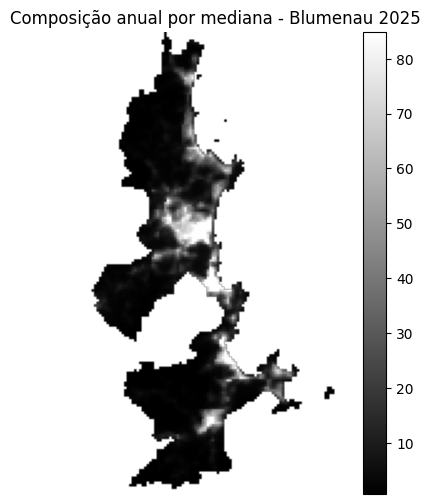

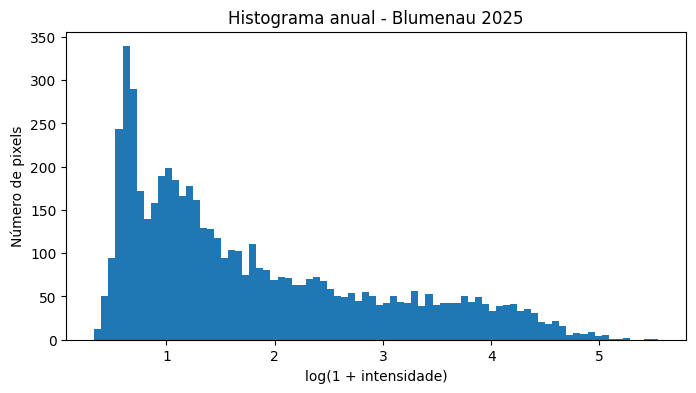

In [ ]:
def visualizar_composicao_anual(regiao_id, ano):
    imagem_anual = montar_composicao_anual(regiao_id, ano)

    dados_pixel = imagem_anual['array']
    mostrar_raster(dados_pixel, f'Composição anual por {METODO_COMPOSICAO} - {nome_regiao(regiao_id)} {ano}')
    histograma_raster(dados_pixel, f'Histograma anual - {nome_regiao(regiao_id)} {ano}')


REGIAO_EXEMPLO = sorted(df_arquivos['regiao_id'].unique())[0]
ANO_EXEMPLO = int(df_arquivos[df_arquivos['regiao_id'] == REGIAO_EXEMPLO]['ano'].max())
visualizar_composicao_anual(REGIAO_EXEMPLO, ANO_EXEMPLO)


## 9. Gerar máscara de área iluminada

A previsão de expansão depende de transformar a intensidade contínua em uma máscara binária:

- `0`: não iluminado
- `1`: iluminado

Para o protótipo, usamos Otsu em `log(1 + intensidade)`. Isso é automático e fácil de explicar, mas no relatório você deve mencionar que o limiar influencia o resultado.


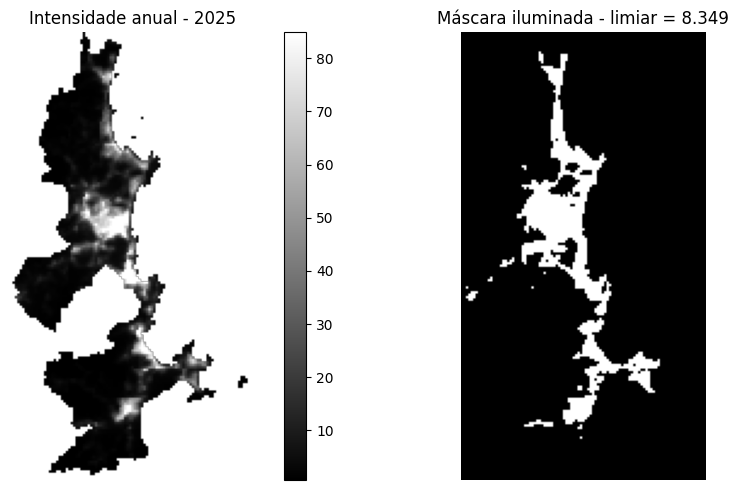

In [95]:
def calcular_limiar_otsu_log(arr):
    valido = arr[np.isfinite(arr)]
    valido = valido[valido > 0]

    if valido.size < 50:
        return np.nan

    logv = np.log1p(valido)

    try:
        t_log = threshold_otsu(logv)
        return float(np.expm1(t_log))
    except Exception:
        return float(np.nanpercentile(valido, 75))


def gerar_mascara_iluminada(arr, limiar=None):
    if limiar is None:
        limiar = calcular_limiar_otsu_log(arr)

    if not np.isfinite(limiar):
        return np.zeros_like(arr, dtype=np.uint8), limiar

    mask = np.zeros_like(arr, dtype=np.uint8)
    mask[(np.isfinite(arr)) & (arr >= limiar)] = 1
    return mask, limiar


def visualizar_mascara(regiao_id, ano):
    comp = montar_composicao_anual(regiao_id, ano)
    if comp is None:
        print(f'Sem composição para {nome_regiao(regiao_id)} {ano}.')
        return

    arr = comp['array']
    mask, limiar = gerar_mascara_iluminada(arr)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    valido = arr[np.isfinite(arr)]
    vmin, vmax = np.nanpercentile(valido, [2, 98])
    plt.imshow(arr, cmap='gray', vmin=vmin, vmax=vmax)
    plt.title(f'Intensidade anual - {ano}')
    plt.axis('off')
    plt.colorbar(fraction=0.046, pad=0.04)

    plt.subplot(1, 2, 2)
    plt.imshow(mask, cmap='gray')
    plt.title(f'Máscara iluminada - limiar = {limiar:.3f}')
    plt.axis('off')

    plt.tight_layout()
    plt.show()


if len(df_arquivos) > 0:
    visualizar_mascara(REGIAO_EXEMPLO, ANO_EXEMPLO)


## 10. Série temporal de área iluminada

Antes de prever, visualize se a área iluminada está crescendo, reduzindo ou oscilando. Isso também ajuda a detectar problemas no limiar.


,regiao,regiao_id,ano,meses_usados,limiar,pixels_validos,pixels_iluminados,percentual_iluminado,media_intensidade,p95_intensidade
0,Blumenau,blumenau,2015,12,5.488320,5608,1465,26.123395,7.924611,42.513508
1,Blumenau,blumenau,2016,12,5.489378,5608,1495,26.658345,8.105818,43.259945
2,Blumenau,blumenau,2017,12,5.540565,5608,1495,26.658345,8.193305,43.229420
3,Blumenau,blumenau,2018,12,5.679510,5608,1543,27.514265,8.669964,46.128071
4,Blumenau,blumenau,2019,12,5.887914,5608,1592,28.388017,8.828853,45.396618
5,Blumenau,blumenau,2020,12,5.906130,5608,1584,28.245364,8.928268,46.643803
6,Blumenau,blumenau,2021,12,5.958550,5608,1626,28.994294,9.083185,46.914124
7,Blumenau,blumenau,2022,12,7.074179,5608,1617,28.833809,10.450506,51.803474
8,Blumenau,blumenau,2023,12,7.759841,5608,1620,28.887304,11.251714,55.761696
9,Blumenau,blumenau,2024,12,7.757483,5608,1734,30.920114,11.530897,56.739693


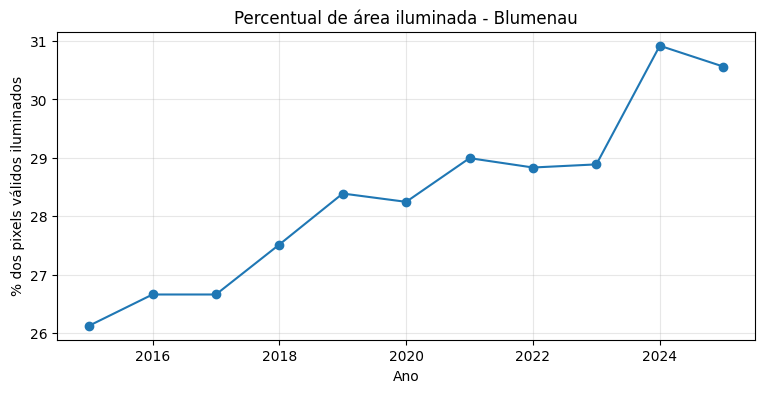

In [96]:
def resumo_area_iluminada(regiao_id):
    linhas = []

    for ano in anos_com_composicao(regiao_id):
        comp = montar_composicao_anual(regiao_id, ano)
        arr = comp['array']
        mask, limiar = gerar_mascara_iluminada(arr)
        validos = np.isfinite(arr)

        linhas.append({
            'regiao': nome_regiao(regiao_id),
            'regiao_id': regiao_id,
            'ano': ano,
            'meses_usados': comp['n_meses'],
            'limiar': limiar,
            'pixels_validos': int(validos.sum()),
            'pixels_iluminados': int(mask.sum()),
            'percentual_iluminado': float(mask.sum() / max(validos.sum(), 1) * 100),
            'media_intensidade': float(np.nanmean(arr)),
            'p95_intensidade': float(np.nanpercentile(arr, 95)),
        })

    return pd.DataFrame(linhas)


def plotar_serie_area(regiao_id):
    df = resumo_area_iluminada(regiao_id)
    if len(df) == 0:
        print('Sem dados para série temporal.')
        return df

    display(df)

    plt.figure(figsize=(9, 4))
    plt.plot(df['ano'], df['percentual_iluminado'], marker='o')
    plt.title(f'Percentual de área iluminada - {nome_regiao(regiao_id)}')
    plt.xlabel('Ano')
    plt.ylabel('% dos pixels válidos iluminados')
    plt.grid(True, alpha=0.3)
    plt.show()

    return df


if len(df_arquivos) > 0:
    _ = plotar_serie_area(REGIAO_EXEMPLO)


## 11. Features espaciais e temporais por pixel

O Random Forest não usa apenas o valor do pixel. Ele recebe também informações da vizinhança e do histórico recente.

Principais variáveis:

- intensidade atual em `log(1 + valor)`
- intensidade do ano anterior
- crescimento recente
- média e desvio-padrão da vizinhança
- proporção de vizinhos iluminados
- distância até a área iluminada mais próxima
- coordenadas normalizadas do pixel


In [97]:
FEATURE_NAMES = [
    'log_intensidade_atual',
    'log_intensidade_anterior',
    'crescimento_log_recente',
    'media_3x3_log',
    'std_3x3_log',
    'media_7x7_log',
    'prop_vizinhos_iluminados_3x3',
    'distancia_ate_luz_norm',
    'linha_norm',
    'coluna_norm',
]


def nanmean_filter(arr, size):
    arr = arr.astype(np.float32)
    valid = np.isfinite(arr).astype(np.float32)
    arr0 = np.where(np.isfinite(arr), arr, 0).astype(np.float32)

    soma = ndimage.uniform_filter(arr0, size=size, mode='nearest') * (size * size)
    cont = ndimage.uniform_filter(valid, size=size, mode='nearest') * (size * size)

    return soma / np.maximum(cont, 1)


def nanstd_filter(arr, size):
    media = nanmean_filter(arr, size)
    media2 = nanmean_filter(arr ** 2, size)
    var = np.maximum(media2 - media ** 2, 0)
    return np.sqrt(var)


def extrair_features_mapa(img_atual, img_anterior=None, mascara_atual=None):
    img_atual = img_atual.astype(np.float32)

    if img_anterior is None:
        img_anterior = img_atual.copy()
    else:
        img_anterior = img_anterior.astype(np.float32)

    if mascara_atual is None:
        mascara_atual, _ = gerar_mascara_iluminada(img_atual)

    log_atual = np.log1p(np.where(np.isfinite(img_atual), np.maximum(img_atual, 0), np.nan)).astype(np.float32)
    log_ant = np.log1p(np.where(np.isfinite(img_anterior), np.maximum(img_anterior, 0), np.nan)).astype(np.float32)
    crescimento = log_atual - log_ant

    media_3 = nanmean_filter(log_atual, 3)
    std_3 = nanstd_filter(log_atual, 3)
    media_7 = nanmean_filter(log_atual, 7)

    prop_vizinhos = ndimage.uniform_filter(mascara_atual.astype(np.float32), size=3, mode='nearest')

    if mascara_atual.sum() > 0:
        distancia = ndimage.distance_transform_edt(mascara_atual == 0).astype(np.float32)
        maxd = np.nanmax(distancia)
        distancia_norm = distancia / max(maxd, 1)
    else:
        distancia_norm = np.ones_like(img_atual, dtype=np.float32)

    h, w = img_atual.shape
    linha_norm = np.linspace(0, 1, h, dtype=np.float32)[:, None] * np.ones((1, w), dtype=np.float32)
    coluna_norm = np.ones((h, 1), dtype=np.float32) * np.linspace(0, 1, w, dtype=np.float32)[None, :]

    features = np.stack([
        log_atual,
        log_ant,
        crescimento,
        media_3,
        std_3,
        media_7,
        prop_vizinhos,
        distancia_norm,
        linha_norm,
        coluna_norm,
    ], axis=-1).astype(np.float32)

    valid = np.all(np.isfinite(features), axis=-1) & np.isfinite(img_atual)
    return features, valid


## 12. Construção do dataset supervisionado

Para cada par de anos `t -> t+1`, o modelo aprende:

```text
X = informações do pixel no ano t
Y_classificação = se o pixel estará iluminado no ano t+1
Y_regressão = intensidade do pixel no ano t+1
```

A classificação gera a máscara futura. A regressão é usada como apoio para projeções recursivas de mais de um ano.


In [98]:
def obter_composicao_array(regiao_id, ano):
    comp = montar_composicao_anual(regiao_id, ano)
    if comp is None:
        return None, None
    return comp['array'], comp['profile']


def amostrar_indices_balanceado(y, valid, max_por_classe=MAX_PIXELS_POR_CLASSE, random_state=RANDOM_STATE):
    rng = np.random.default_rng(random_state)
    y_flat = y.ravel()
    valid_flat = valid.ravel()

    idx_valid = np.flatnonzero(valid_flat)
    idx_pos = idx_valid[y_flat[idx_valid] == 1]
    idx_neg = idx_valid[y_flat[idx_valid] == 0]

    if len(idx_pos) == 0 or len(idx_neg) == 0:
        # Se só houver uma classe, pega amostra aleatória geral.
        n = min(len(idx_valid), 2 * max_por_classe)
        return rng.choice(idx_valid, size=n, replace=False) if n > 0 else np.array([], dtype=int)

    n_pos = min(len(idx_pos), max_por_classe)
    n_neg = min(len(idx_neg), max_por_classe)

    idx_pos_s = rng.choice(idx_pos, size=n_pos, replace=False)
    idx_neg_s = rng.choice(idx_neg, size=n_neg, replace=False)

    idx = np.concatenate([idx_pos_s, idx_neg_s])
    rng.shuffle(idx)
    return idx


def amostrar_indices_regressao(valid, max_pixels=MAX_PIXELS_REGRESSAO_POR_PAR, random_state=RANDOM_STATE):
    rng = np.random.default_rng(random_state)
    idx_valid = np.flatnonzero(valid.ravel())
    n = min(len(idx_valid), max_pixels)
    if n == 0:
        return np.array([], dtype=int)
    return rng.choice(idx_valid, size=n, replace=False)


def preparar_par_tempo(regiao_id, ano_t):
    """Monta X e y para o par ano_t -> ano_t+1."""
    img_t, profile_t = obter_composicao_array(regiao_id, ano_t)
    img_next, _ = obter_composicao_array(regiao_id, ano_t + 1)

    if img_t is None or img_next is None:
        return None

    img_prev, _ = obter_composicao_array(regiao_id, ano_t - 1)
    if img_prev is None:
        img_prev = img_t.copy()

    # Garante mesmo shape. Como todas as composições foram reprojetadas para a referência da região,
    # isto normalmente já estará correto.
    if img_next.shape != img_t.shape:
        raise ValueError(f'Shapes diferentes em {nome_regiao(regiao_id)} {ano_t}->{ano_t+1}: {img_t.shape} vs {img_next.shape}')

    mascara_t, limiar_t = gerar_mascara_iluminada(img_t)
    mascara_next, limiar_next = gerar_mascara_iluminada(img_next)

    features, valid_features = extrair_features_mapa(img_t, img_prev, mascara_t)
    valid = valid_features & np.isfinite(img_next)

    y_class = mascara_next.astype(np.uint8)
    y_reg = np.log1p(np.where(np.isfinite(img_next), np.maximum(img_next, 0), 0)).astype(np.float32)

    return {
        'ano_t': ano_t,
        'img_t': img_t,
        'img_next': img_next,
        'mascara_t': mascara_t,
        'mascara_next': mascara_next,
        'limiar_t': limiar_t,
        'limiar_next': limiar_next,
        'features': features,
        'valid': valid,
        'y_class': y_class,
        'y_reg': y_reg,
    }


def construir_dataset_treino(regiao_id, anos_treino):
    Xc_list, yc_list = [], []
    Xr_list, yr_list = [], []
    pares_usados = []

    for ano_t in anos_treino:
        par = preparar_par_tempo(regiao_id, ano_t)
        if par is None:
            print(f'Ignorando {ano_t}->{ano_t+1}: dados insuficientes.')
            continue

        feats = par['features']
        y_class = par['y_class']
        y_reg = par['y_reg']
        valid = par['valid']

        idx_c = amostrar_indices_balanceado(y_class, valid, random_state=RANDOM_STATE + ano_t)
        idx_r = amostrar_indices_regressao(valid, random_state=RANDOM_STATE + ano_t + 1000)

        if len(idx_c) > 0:
            Xc_list.append(feats.reshape(-1, feats.shape[-1])[idx_c])
            yc_list.append(y_class.ravel()[idx_c])

        if len(idx_r) > 0:
            Xr_list.append(feats.reshape(-1, feats.shape[-1])[idx_r])
            yr_list.append(y_reg.ravel()[idx_r])

        pares_usados.append(f'{ano_t}->{ano_t+1}')

    if len(Xc_list) == 0:
        return None

    Xc = np.vstack(Xc_list).astype(np.float32)
    yc = np.concatenate(yc_list).astype(np.uint8)
    Xr = np.vstack(Xr_list).astype(np.float32) if len(Xr_list) > 0 else None
    yr = np.concatenate(yr_list).astype(np.float32) if len(yr_list) > 0 else None

    return Xc, yc, Xr, yr, pares_usados


## 13. Treino e validação temporal

A validação correta não deve embaralhar os anos. O notebook testa assim:

- Treina com anos anteriores.
- Testa em `2024 -> 2025`, porque 2025 já existe.
- Depois usa os dados até 2025 para prever 2026.

Isso responde à pergunta: **“como saber se a previsão está correta?”**


In [99]:
def melhor_limiar_por_f1(y_true, probas):
    candidatos = np.linspace(0.1, 0.9, 81)
    melhor_t = 0.5
    melhor_f1 = -1

    for t in candidatos:
        pred = (probas >= t).astype(np.uint8)
        f1 = f1_score(y_true, pred, zero_division=0)
        if f1 > melhor_f1:
            melhor_f1 = f1
            melhor_t = float(t)

    return melhor_t, melhor_f1


def calcular_metricas_classificacao(y_true, probas, threshold=0.5):
    y_pred = (probas >= threshold).astype(np.uint8)
    out = {
        'threshold': threshold,
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
    }
    if len(np.unique(y_true)) == 2:
        out['roc_auc'] = roc_auc_score(y_true, probas)
    else:
        out['roc_auc'] = np.nan
    return out


def treinar_validar_regiao(regiao_id, ano_teste=2024):
    anos = anos_com_composicao(regiao_id)
    print(f'Região: {nome_regiao(regiao_id)}')
    print('Anos com composição:', anos)

    if ano_teste not in anos or (ano_teste + 1) not in anos:
        print(f'Não é possível validar {ano_teste}->{ano_teste+1}; faltam composições anuais.')
        return None

    anos_treino = [a for a in anos if a < ano_teste and (a + 1) in anos]
    if len(anos_treino) < 2:
        print('Poucos pares temporais para treino. Use a série completa 2015-2025.')
        return None

    dados = construir_dataset_treino(regiao_id, anos_treino)
    if dados is None:
        print('Não foi possível construir dataset de treino.')
        return None

    Xc, yc, Xr, yr, pares_usados = dados
    print('Pares usados no treino:', pares_usados)
    print('X classificação:', Xc.shape, '| y:', np.bincount(yc))

    clf = RandomForestClassifier(
        n_estimators=250,
        max_depth=None,
        min_samples_leaf=2,
        class_weight='balanced_subsample',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    clf.fit(Xc, yc)

    reg = None
    if Xr is not None and yr is not None and len(yr) > 0:
        print('X regressão:', Xr.shape)
        reg = RandomForestRegressor(
            n_estimators=160,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        reg.fit(Xr, yr)

    par_teste = preparar_par_tempo(regiao_id, ano_teste)
    feats = par_teste['features']
    valid = par_teste['valid']
    X_test = feats.reshape(-1, feats.shape[-1])[valid.ravel()]
    y_true = par_teste['y_class'].ravel()[valid.ravel()]

    prob = np.zeros(par_teste['img_t'].size, dtype=np.float32)
    prob_valid = clf.predict_proba(X_test)[:, 1].astype(np.float32)
    prob[valid.ravel()] = prob_valid
    prob_map = prob.reshape(par_teste['img_t'].shape)

    melhor_t, melhor_f1 = melhor_limiar_por_f1(y_true, prob_valid)
    metricas_05 = calcular_metricas_classificacao(y_true, prob_valid, threshold=0.5)
    metricas_best = calcular_metricas_classificacao(y_true, prob_valid, threshold=melhor_t)

    # Baseline: persistência. Assume que o ano seguinte será igual ao ano atual.
    y_persist = par_teste['mascara_t'].ravel()[valid.ravel()]
    metricas_persist = {
        'f1': f1_score(y_true, y_persist, zero_division=0),
        'precision': precision_score(y_true, y_persist, zero_division=0),
        'recall': recall_score(y_true, y_persist, zero_division=0),
    }

    print('\nMétricas usando threshold 0.50:')
    display(pd.DataFrame([metricas_05]))

    print(f'Melhor threshold por F1 no backtest: {melhor_t:.2f}')
    display(pd.DataFrame([metricas_best]))

    print('Baseline de persistência: máscara futura = máscara atual')
    display(pd.DataFrame([metricas_persist]))

    y_pred_best = (prob_valid >= melhor_t).astype(np.uint8)
    cm = confusion_matrix(y_true, y_pred_best, labels=[0, 1])
    print('Matriz de confusão [[TN, FP], [FN, TP]]:')
    print(cm)

    metricas_reg = None
    pred_reg_map = None
    if reg is not None:
        pred_log = np.zeros(par_teste['img_t'].size, dtype=np.float32)
        pred_log_valid = reg.predict(X_test).astype(np.float32)
        pred_log[valid.ravel()] = pred_log_valid
        pred_reg_map = np.expm1(pred_log.reshape(par_teste['img_t'].shape)).astype(np.float32)
        y_reg_true = par_teste['y_reg'].ravel()[valid.ravel()]
        rmse = math.sqrt(mean_squared_error(y_reg_true, pred_log_valid))
        mae = mean_absolute_error(y_reg_true, pred_log_valid)
        metricas_reg = {'mae_log_intensidade': mae, 'rmse_log_intensidade': rmse}
        print('Métricas da regressão auxiliar de intensidade em log1p:')
        display(pd.DataFrame([metricas_reg]))

    return {
        'regiao_id': regiao_id,
        'ano_teste': ano_teste,
        'modelo_classificador': clf,
        'modelo_regressor': reg,
        'feature_names': FEATURE_NAMES,
        'threshold_sugerido': melhor_t,
        'metricas_threshold_05': metricas_05,
        'metricas_threshold_otimo': metricas_best,
        'metricas_persistencia': metricas_persist,
        'metricas_regressao': metricas_reg,
        'par_teste': par_teste,
        'prob_map': prob_map,
        'pred_reg_map': pred_reg_map,
    }


### Visualização do backtest temporal

Esta é uma das figuras mais importantes para mostrar ao professor.


In [100]:
def visualizar_backtest(resultado):
    if resultado is None:
        print('Sem resultado de validação para visualizar.')
        return

    par = resultado['par_teste']
    t = resultado['threshold_sugerido']
    prob = resultado['prob_map']
    pred_mask = (prob >= t).astype(np.uint8)
    real_mask = par['mascara_next']
    mask_t = par['mascara_t']

    # Mapa de erro:
    # 0 = correto escuro, 1 = correto iluminado, 2 = falso negativo, 3 = falso positivo
    erro = np.zeros_like(real_mask, dtype=np.uint8)
    erro[(pred_mask == 1) & (real_mask == 1)] = 1
    erro[(pred_mask == 0) & (real_mask == 1)] = 2
    erro[(pred_mask == 1) & (real_mask == 0)] = 3

    ano_t = resultado['ano_teste']
    ano_next = ano_t + 1

    plt.figure(figsize=(18, 10))

    plt.subplot(2, 3, 1)
    plt.imshow(mask_t, cmap='gray')
    plt.title(f'Máscara real {ano_t}')
    plt.axis('off')

    plt.subplot(2, 3, 2)
    plt.imshow(prob, cmap='viridis', vmin=0, vmax=1)
    plt.title(f'Probabilidade prevista {ano_next}')
    plt.axis('off')
    plt.colorbar(fraction=0.046, pad=0.04)

    plt.subplot(2, 3, 3)
    plt.imshow(pred_mask, cmap='gray')
    plt.title(f'Máscara prevista {ano_next}')
    plt.axis('off')

    plt.subplot(2, 3, 4)
    plt.imshow(real_mask, cmap='gray')
    plt.title(f'Máscara real {ano_next}')
    plt.axis('off')

    plt.subplot(2, 3, 5)
    plt.imshow(erro, cmap='tab10', vmin=0, vmax=3)
    plt.title('Erro espacial\n0 ok escuro | 1 ok luz | 2 FN | 3 FP')
    plt.axis('off')
    plt.colorbar(fraction=0.046, pad=0.04)

    expansao_real = (real_mask == 1) & (mask_t == 0)
    expansao_prev = (pred_mask == 1) & (mask_t == 0)

    comparacao_exp = np.zeros_like(real_mask, dtype=np.uint8)
    comparacao_exp[(expansao_real == 1) & (expansao_prev == 1)] = 1
    comparacao_exp[(expansao_real == 1) & (expansao_prev == 0)] = 2
    comparacao_exp[(expansao_real == 0) & (expansao_prev == 1)] = 3

    plt.subplot(2, 3, 6)
    plt.imshow(comparacao_exp, cmap='tab10', vmin=0, vmax=3)
    plt.title('Expansão no backtest\n1 acerto | 2 perdeu | 3 excedeu')
    plt.axis('off')
    plt.colorbar(fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

    print('Pixels de expansão real:', int(expansao_real.sum()))
    print('Pixels de expansão prevista:', int(expansao_prev.sum()))


## 14. Executar validação para uma região

Escolha uma região encontrada no inventário. O notebook tentará validar `2024 -> 2025`. Se faltar a série completa, ele avisará em vez de quebrar.


In [101]:
if len(df_arquivos) > 0:
    regioes = sorted(df_arquivos['regiao_id'].unique())
    print('Regiões disponíveis:')
    for i, r in enumerate(regioes):
        print(f'{i}: {r} ({nome_regiao(r)})')

    # Altere aqui se quiser outra região.
    REGIAO_MODELO = regioes[0]
    print('\nRegião selecionada:', REGIAO_MODELO, '=>', nome_regiao(REGIAO_MODELO))
else:
    REGIAO_MODELO = None


Regiões disponíveis:
0: blumenau (Blumenau)
1: criciuma (Criciuma)
2: florianopolis (Florianopolis)
3: joinville (Joinville)

Região selecionada: blumenau => Blumenau


Região: Blumenau
Anos com composição: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Pares usados no treino: ['2015->2016', '2016->2017', '2017->2018', '2018->2019', '2019->2020', '2020->2021', '2021->2022', '2022->2023', '2023->2024']
X classificação: (50472, 10) | y: [36166 14306]
X regressão: (50472, 10)

Métricas usando threshold 0.50:


,threshold,f1,precision,recall,roc_auc
0,0.5,0.939199,0.903504,0.97783,0.996126


Melhor threshold por F1 no backtest: 0.84


,threshold,f1,precision,recall,roc_auc
0,0.84,0.957993,0.957993,0.957993,0.996126


Baseline de persistência: máscara futura = máscara atual


,f1,precision,recall
0,0.957657,0.952134,0.963244


Matriz de confusão [[TN, FP], [FN, TP]]:
[[3822   72]
 [  72 1642]]
Métricas da regressão auxiliar de intensidade em log1p:


,mae_log_intensidade,rmse_log_intensidade
0,0.105827,0.146451


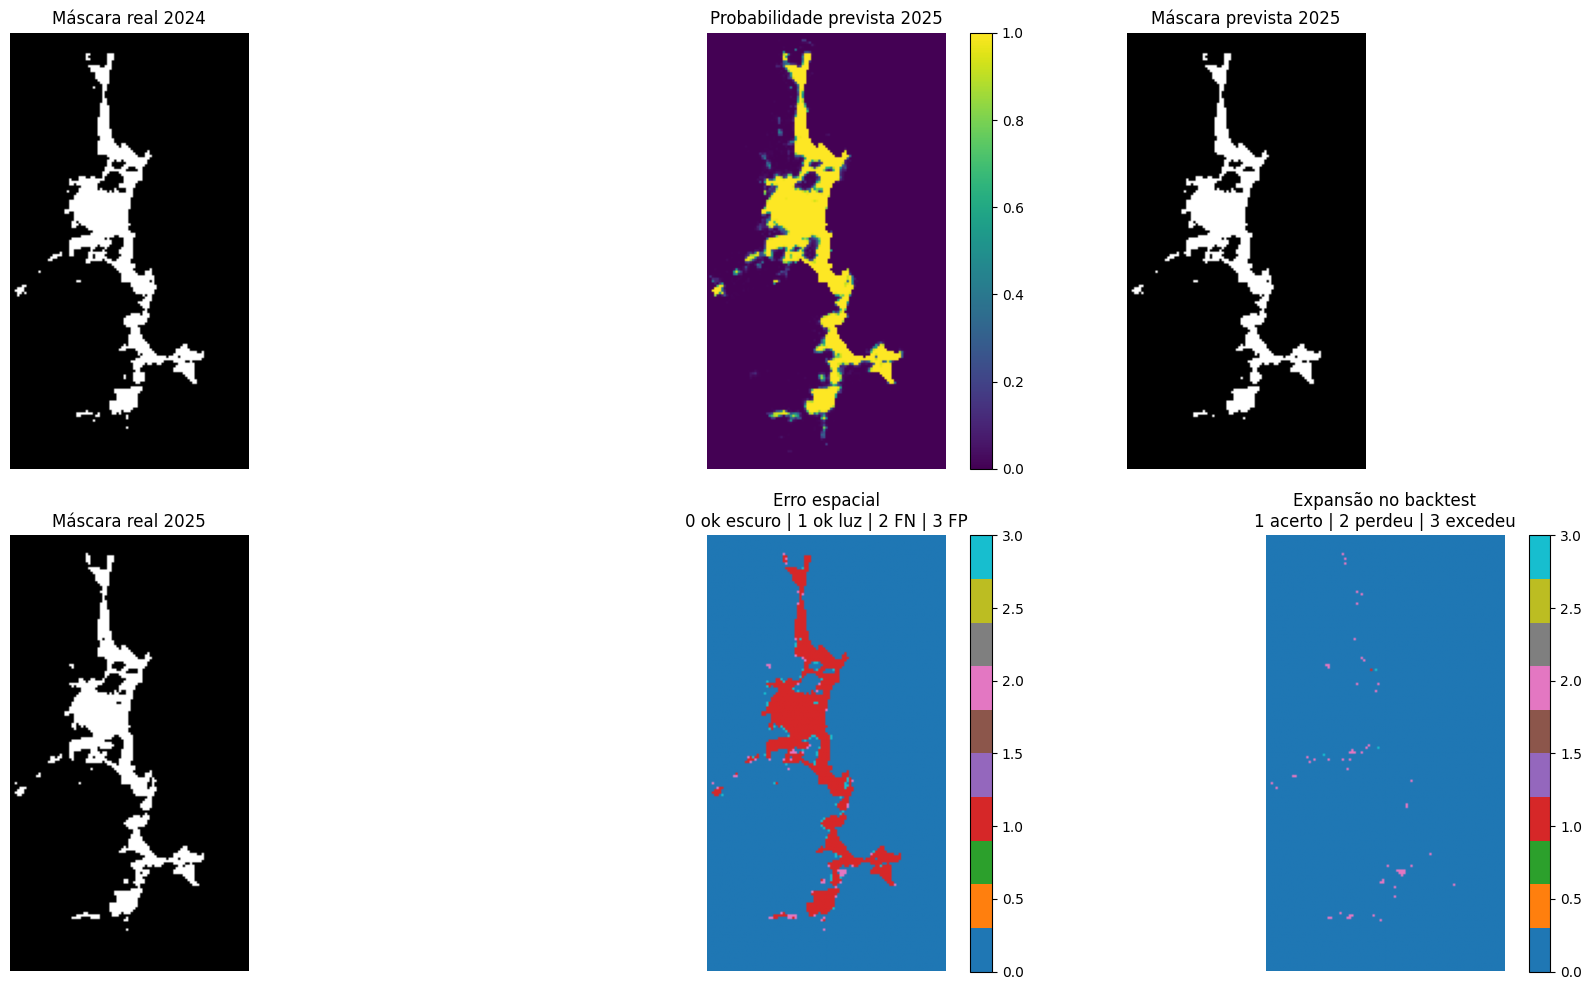

Pixels de expansão real: 63
Pixels de expansão prevista: 4


In [102]:
resultado_validacao = None

if REGIAO_MODELO is not None:
    resultado_validacao = treinar_validar_regiao(REGIAO_MODELO, ano_teste=2024)
    visualizar_backtest(resultado_validacao)


## 15. Importância das variáveis

Esta figura ajuda a explicar o que o modelo está usando para decidir.


,feature,importancia
0,log_intensidade_atual,0.304468
7,distancia_ate_luz_norm,0.203690
1,log_intensidade_anterior,0.190599
6,prop_vizinhos_iluminados_3x3,0.125144
3,media_3x3_log,0.080905
5,media_7x7_log,0.058355
4,std_3x3_log,0.014466
2,crescimento_log_recente,0.008147
9,coluna_norm,0.008056
8,linha_norm,0.006171


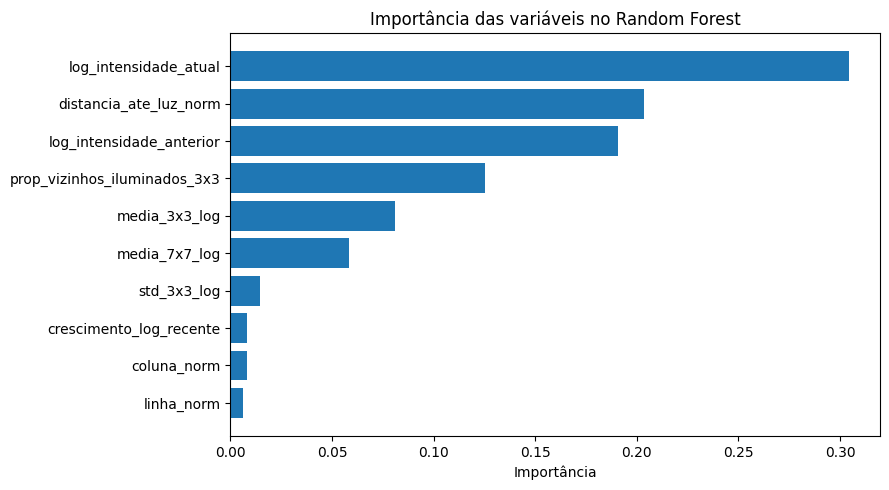

In [103]:
def visualizar_importancia_features(resultado, top_n=15):
    if resultado is None:
        print('Sem modelo treinado.')
        return

    clf = resultado['modelo_classificador']
    importancias = pd.DataFrame({
        'feature': resultado['feature_names'],
        'importancia': clf.feature_importances_,
    }).sort_values('importancia', ascending=False)

    display(importancias)

    plt.figure(figsize=(9, 5))
    plt.barh(importancias['feature'].head(top_n)[::-1], importancias['importancia'].head(top_n)[::-1])
    plt.title('Importância das variáveis no Random Forest')
    plt.xlabel('Importância')
    plt.tight_layout()
    plt.show()


visualizar_importancia_features(resultado_validacao)


## 16. Treinar com todos os anos disponíveis e prever anos futuros

A previsão principal é o primeiro ano após o último ano real, por exemplo `2026` quando o último ano real é `2025`.

Previsões de `2027`, `2028`, etc. são projeções recursivas: usam previsões anteriores como entrada. Portanto, devem ser apresentadas como **cenários exploratórios**, não como certeza.


## 16.1 Correção importante: previsão acumulada de expansão

Se a máscara futura for prevista livremente, o modelo pode apagar pixels que já estavam iluminados. Isso gera uma tabela com menos pixels iluminados no futuro e `pixels_expansao_nova = 0`, ou seja, uma **desexpansão**.

Para este trabalho, a saída principal deve ser tratada como **cenário acumulado de expansão**:

```python
mascara_futura = mascara_atual | expansao_nova_prevista
```

Assim, o Random Forest passa a prever principalmente **quais pixels escuros têm chance de virar iluminados**. Pixels já iluminados são mantidos como parte da área iluminada acumulada. Isso não significa dizer que a luz real nunca possa diminuir; é uma escolha metodológica para estudar **expansão espacial**.



In [104]:
def amostrar_indices_expansao(y_expand, valid, max_por_classe=MAX_PIXELS_POR_CLASSE, random_state=RANDOM_STATE):
    """Amostra pixels para treinar expansão nova: 1 = escuro em t e iluminado em t+1."""
    return amostrar_indices_balanceado(y_expand, valid, max_por_classe=max_por_classe, random_state=random_state)


def construir_dataset_expansao(regiao_id, anos_treino):
    """
    Constrói dataset específico para expansão nova.

    Alvo:
    - 1: pixel estava escuro em t e virou iluminado em t+1
    - 0: pixel estava escuro em t e continuou escuro em t+1

    Pixels já iluminados em t são removidos, porque eles não representam expansão nova.
    """
    X_list, y_list = [], []
    pares_usados = []
    contagens = []

    for ano_t in anos_treino:
        par = preparar_par_tempo(regiao_id, ano_t)
        if par is None:
            continue

        feats = par['features']
        mask_t = par['mascara_t']
        mask_next = par['mascara_next']
        valid = par['valid'] & (mask_t == 0)  # só pixels ainda escuros podem virar expansão nova

        y_expand = ((mask_next == 1) & (mask_t == 0)).astype(np.uint8)
        idx = amostrar_indices_expansao(y_expand, valid, random_state=RANDOM_STATE + ano_t + 5000)

        if len(idx) == 0:
            continue

        X_list.append(feats.reshape(-1, feats.shape[-1])[idx])
        y_list.append(y_expand.ravel()[idx])
        pares_usados.append(f'{ano_t}->{ano_t+1}')
        contagens.append({
            'par': f'{ano_t}->{ano_t+1}',
            'expansao_real_pixels': int(y_expand[valid].sum()),
            'pixels_escuros_validos': int(valid.sum()),
        })

    if len(X_list) == 0:
        return None

    X = np.vstack(X_list).astype(np.float32)
    y = np.concatenate(y_list).astype(np.uint8)
    return X, y, pares_usados, pd.DataFrame(contagens)


def treinar_modelos_finais(regiao_id, ano_base=ANO_BASE_PREVISAO):
    anos = anos_com_composicao(regiao_id)
    anos_treino = [a for a in anos if a < ano_base and (a + 1) in anos]

    if len(anos_treino) < 2:
        print('Poucos pares para treinar modelos finais. Verifique se a série 2015-2025 está disponível.')
        return None

    # Modelo de estado iluminado futuro, útil para mapa de probabilidade geral.
    dados_estado = construir_dataset_treino(regiao_id, anos_treino)
    if dados_estado is None:
        return None

    Xc, yc, Xr, yr, pares_usados = dados_estado
    print('Treino final usando pares:', pares_usados)
    print('Amostras classificação de estado:', Xc.shape, 'classes:', np.bincount(yc))

    clf_estado = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        class_weight='balanced_subsample',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    clf_estado.fit(Xc, yc)

    # Modelo específico de expansão nova.
    dados_exp = construir_dataset_expansao(regiao_id, anos_treino)
    clf_expansao = None
    if dados_exp is not None:
        Xe, ye, pares_exp, tabela_exp = dados_exp
        print('\nAmostras classificação de expansão nova:', Xe.shape, 'classes:', np.bincount(ye))
        display(tabela_exp)

        if len(np.unique(ye)) == 2 and ye.sum() > 0:
            clf_expansao = RandomForestClassifier(
                n_estimators=300,
                max_depth=None,
                min_samples_leaf=1,
                class_weight='balanced_subsample',
                random_state=RANDOM_STATE,
                n_jobs=-1,
            )
            clf_expansao.fit(Xe, ye)
        else:
            print('Aviso: não foram encontrados exemplos suficientes de expansão nova. Usarei o modelo de estado com persistência.')
    else:
        print('Aviso: não foi possível montar dataset de expansão nova. Usarei o modelo de estado com persistência.')

    reg = None
    if Xr is not None and yr is not None and len(yr) > 0:
        print('\nAmostras regressão:', Xr.shape)
        reg = RandomForestRegressor(
            n_estimators=180,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        reg.fit(Xr, yr)

    threshold_estado = LIMIAR_PROBABILIDADE_PADRAO
    if resultado_validacao is not None and resultado_validacao.get('regiao_id') == regiao_id:
        # Esse threshold é bom para classificar a área iluminada geral,
        # mas pode ser alto demais para expansão nova.
        threshold_estado = resultado_validacao['threshold_sugerido']

    return {
        'classificador_estado': clf_estado,
        'classificador_expansao': clf_expansao,
        'regressor': reg,
        'threshold_estado': threshold_estado,
        'threshold_expansao': LIMIAR_EXPANSAO_PADRAO,
        'pares_usados': pares_usados,
    }


def salvar_geotiff(caminho_saida, arr, profile, dtype=None, nodata=None):
    caminho_saida = Path(caminho_saida)
    caminho_saida.parent.mkdir(parents=True, exist_ok=True)

    profile_out = profile.copy()
    profile_out.update(count=1, compress='lzw')

    if dtype is None:
        dtype = arr.dtype
    profile_out.update(dtype=dtype)

    if nodata is not None:
        profile_out.update(nodata=nodata)

    with rasterio.open(caminho_saida, 'w', **profile_out) as dst:
        dst.write(arr.astype(dtype), 1)


def prever_anos_futuros(regiao_id, ano_base=ANO_BASE_PREVISAO, anos_a_frente=ANOS_A_PREVER):
    modelos = treinar_modelos_finais(regiao_id, ano_base=ano_base)
    if modelos is None:
        return None

    img_base, profile = obter_composicao_array(regiao_id, ano_base)
    if img_base is None:
        print(f'Não existe composição para o ano base {ano_base}.')
        return None

    img_atual = img_base.copy()
    img_anterior, _ = obter_composicao_array(regiao_id, ano_base - 1)
    if img_anterior is None:
        img_anterior = img_atual.copy()

    mask_base, limiar_base = gerar_mascara_iluminada(img_base)
    mask_atual = mask_base.copy()

    clf_estado = modelos['classificador_estado']
    clf_expansao = modelos['classificador_expansao']
    reg = modelos['regressor']
    threshold_estado = modelos['threshold_estado']
    threshold_expansao = modelos['threshold_expansao']

    saidas = []
    out_dir = Path(DATA_DIR) / 'resultados_previsao_ntl' / normalizar_texto(nome_regiao(regiao_id))
    out_dir.mkdir(parents=True, exist_ok=True)

    for passo in range(1, anos_a_frente + 1):
        ano_previsto = ano_base + passo

        features, valid = extrair_features_mapa(img_atual, img_anterior, mask_atual)
        X = features.reshape(-1, features.shape[-1])[valid.ravel()]

        prob_estado_flat = np.zeros(img_atual.size, dtype=np.float32)
        if len(X) > 0:
            prob_estado_flat[valid.ravel()] = clf_estado.predict_proba(X)[:, 1].astype(np.float32)
        prob_estado = prob_estado_flat.reshape(img_atual.shape)

        # Probabilidade de expansão nova: preferencialmente vem do modelo específico de expansão.
        prob_expansao = np.zeros_like(prob_estado, dtype=np.float32)
        candidatos_expansao = valid & (mask_atual == 0)

        if clf_expansao is not None and candidatos_expansao.sum() > 0:
            X_exp = features.reshape(-1, features.shape[-1])[candidatos_expansao.ravel()]
            prob_exp_flat = clf_expansao.predict_proba(X_exp)[:, 1].astype(np.float32)
            prob_expansao.ravel()[candidatos_expansao.ravel()] = prob_exp_flat
            expansao = (prob_expansao >= threshold_expansao) & candidatos_expansao
        else:
            # Fallback: usa o modelo de estado, mas só permite expansão em pixels ainda escuros.
            expansao = (prob_estado >= threshold_estado) & candidatos_expansao
            prob_expansao = prob_estado.copy()

        # Esta é a correção contra desexpansão:
        # a saída principal é acumulada, logo pixels já iluminados permanecem iluminados.
        if FORCAR_PERSISTENCIA_AREA_ILUMINADA:
            mask_prevista = ((mask_atual == 1) | expansao).astype(np.uint8)
        else:
            mask_prevista = (prob_estado >= threshold_estado).astype(np.uint8)
            expansao = ((mask_prevista == 1) & (mask_atual == 0))

        expansao = expansao.astype(np.uint8)
        expansao_acumulada = ((mask_prevista == 1) & (mask_base == 0)).astype(np.uint8)

        if reg is not None and len(X) > 0:
            pred_log = np.zeros(img_atual.size, dtype=np.float32)
            pred_log[valid.ravel()] = reg.predict(X).astype(np.float32)
            img_proxima = np.expm1(pred_log.reshape(img_atual.shape)).astype(np.float32)
            img_proxima = np.where(np.isfinite(img_proxima), np.maximum(img_proxima, 0), 0).astype(np.float32)
        else:
            img_proxima = img_atual.copy().astype(np.float32)

        # Garante coerência visual/recursiva: pixels previstos como iluminados não ficam com intensidade abaixo do limiar.
        img_proxima = np.where(mask_prevista == 1, np.maximum(img_proxima, limiar_base), img_proxima).astype(np.float32)

        salvar_geotiff(out_dir / f'probabilidade_estado_iluminado_{ano_previsto}.tif', prob_estado.astype(np.float32), profile, dtype='float32', nodata=None)
        salvar_geotiff(out_dir / f'probabilidade_expansao_{ano_previsto}.tif', prob_expansao.astype(np.float32), profile, dtype='float32', nodata=None)
        salvar_geotiff(out_dir / f'mascara_iluminada_prevista_{ano_previsto}.tif', mask_prevista.astype(np.uint8), profile, dtype='uint8', nodata=0)
        salvar_geotiff(out_dir / f'expansao_nova_prevista_{ano_previsto}.tif', expansao.astype(np.uint8), profile, dtype='uint8', nodata=0)
        salvar_geotiff(out_dir / f'expansao_acumulada_desde_{ano_base}_ate_{ano_previsto}.tif', expansao_acumulada.astype(np.uint8), profile, dtype='uint8', nodata=0)
        salvar_geotiff(out_dir / f'intensidade_prevista_{ano_previsto}.tif', img_proxima.astype(np.float32), profile, dtype='float32', nodata=None)

        saidas.append({
            'ano': ano_previsto,
            'probabilidade': prob_estado,
            'probabilidade_expansao': prob_expansao,
            'mascara_prevista': mask_prevista,
            'expansao': expansao,
            'expansao_acumulada': expansao_acumulada,
            'intensidade_prevista': img_proxima,
            'pixels_expansao': int(expansao.sum()),
            'pixels_expansao_acumulada': int(expansao_acumulada.sum()),
            'pixels_iluminados_previstos': int(mask_prevista.sum()),
            'threshold_estado': threshold_estado,
            'threshold_expansao': threshold_expansao,
        })

        print(
            f'{ano_previsto}: pixels iluminados previstos = {int(mask_prevista.sum())}; '
            f'expansão nova = {int(expansao.sum())}; '
            f'expansão acumulada = {int(expansao_acumulada.sum())}'
        )

        img_anterior = img_atual
        img_atual = img_proxima
        mask_atual = mask_prevista

    print('Arquivos salvos em:', out_dir.resolve())
    return {
        'regiao_id': regiao_id,
        'modelos': modelos,
        'profile': profile,
        'ano_base': ano_base,
        'saidas': saidas,
        'out_dir': out_dir,
    }



### Executar previsão futura


In [105]:
resultado_futuro = None

if REGIAO_MODELO is not None:
    resultado_futuro = prever_anos_futuros(
        REGIAO_MODELO,
        ano_base=ANO_BASE_PREVISAO,
        anos_a_frente=ANOS_A_PREVER,
    )


Treino final usando pares: ['2015->2016', '2016->2017', '2017->2018', '2018->2019', '2019->2020', '2020->2021', '2021->2022', '2022->2023', '2023->2024', '2024->2025']
Amostras classificação de estado: (56080, 10) classes: [40060 16020]

Amostras classificação de expansão nova: (40309, 10) classes: [39565   744]


,par,expansao_real_pixels,pixels_escuros_validos
0,2015->2016,71,4143
1,2016->2017,64,4113
2,2017->2018,83,4113
3,2018->2019,76,4065
4,2019->2020,49,4016
5,2020->2021,73,4024
6,2021->2022,54,3982
7,2022->2023,66,3991
8,2023->2024,145,3988
9,2024->2025,63,3874



Amostras regressão: (56080, 10)
2026: pixels iluminados previstos = 1877; expansão nova = 163; expansão acumulada = 163
2027: pixels iluminados previstos = 1925; expansão nova = 48; expansão acumulada = 211
2028: pixels iluminados previstos = 1974; expansão nova = 49; expansão acumulada = 260
Arquivos salvos em: C:\Users\thomh\Desktop\Pastas\FURB\2026.1\Processamento de Imagens\processamento-de-imagens-luzes-noturnas\src\data\NTL_LITORAL_SC\QGIS_LITORAL\RASTER\NTL_LITORAL\resultados_previsao_ntl\blumenau


## 17. Visualizar mapas previstos


In [106]:
def visualizar_previsoes_futuras(resultado_futuro):
    if resultado_futuro is None:
        print('Sem previsões futuras para visualizar.')
        return

    regiao_id = resultado_futuro['regiao_id']
    ano_base = resultado_futuro['ano_base']
    img_base, _ = obter_composicao_array(regiao_id, ano_base)
    mask_base, _ = gerar_mascara_iluminada(img_base)

    for saida in resultado_futuro['saidas']:
        ano = saida['ano']
        prob_estado = saida['probabilidade']
        prob_exp = saida.get('probabilidade_expansao', prob_estado)
        mask = saida['mascara_prevista']
        expansao = saida['expansao']
        expansao_acumulada = saida.get('expansao_acumulada', expansao)
        intensidade = saida['intensidade_prevista']

        plt.figure(figsize=(18, 9))

        plt.subplot(2, 3, 1)
        valido = img_base[np.isfinite(img_base)]
        if valido.size > 0:
            vmin, vmax = np.nanpercentile(valido, [2, 98])
        else:
            vmin, vmax = 0, 1
        plt.imshow(img_base, cmap='gray', vmin=vmin, vmax=vmax)
        plt.title(f'Imagem real base {ano_base}')
        plt.axis('off')

        plt.subplot(2, 3, 2)
        plt.imshow(prob_exp, cmap='viridis', vmin=0, vmax=1)
        plt.title(f'Probabilidade de expansão nova {ano}')
        plt.axis('off')
        plt.colorbar(fraction=0.046, pad=0.04)

        plt.subplot(2, 3, 3)
        plt.imshow(mask, cmap='gray')
        plt.title(f'Máscara iluminada prevista acumulada {ano}')
        plt.axis('off')

        plt.subplot(2, 3, 4)
        plt.imshow(mask_base, cmap='gray')
        plt.title(f'Máscara real {ano_base}')
        plt.axis('off')

        plt.subplot(2, 3, 5)
        plt.imshow(expansao, cmap='gray')
        plt.title(f'Expansão nova prevista {ano-1}->{ano}')
        plt.axis('off')

        plt.subplot(2, 3, 6)
        plt.imshow(expansao_acumulada, cmap='gray')
        plt.title(f'Expansão acumulada {ano_base}->{ano}')
        plt.axis('off')

        plt.tight_layout()
        plt.show()



## 18. Resumo numérico das previsões


,ano,pixels_iluminados_previstos,pixels_expansao_nova,pixels_expansao_acumulada,percentual_iluminado_previsto,percentual_expansao_nova,percentual_expansao_acumulada,threshold_estado,threshold_expansao
0,2026,1877,163,163,10.045491,0.872358,0.872358,0.84,0.35
1,2027,1925,48,211,10.302382,0.256891,1.129248,0.84,0.35
2,2028,1974,49,260,10.564624,0.262242,1.391491,0.84,0.35


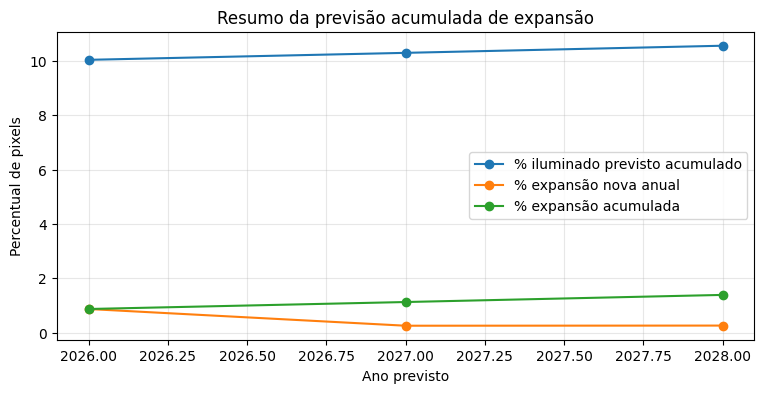

In [107]:
def tabela_resumo_previsoes(resultado_futuro):
    if resultado_futuro is None:
        print('Sem previsões para resumir.')
        return pd.DataFrame()

    linhas = []
    for s in resultado_futuro['saidas']:
        total_pixels = s['mascara_prevista'].size
        linhas.append({
            'ano': s['ano'],
            'pixels_iluminados_previstos': s['pixels_iluminados_previstos'],
            'pixels_expansao_nova': s['pixels_expansao'],
            'pixels_expansao_acumulada': s.get('pixels_expansao_acumulada', s['pixels_expansao']),
            'percentual_iluminado_previsto': s['pixels_iluminados_previstos'] / total_pixels * 100,
            'percentual_expansao_nova': s['pixels_expansao'] / total_pixels * 100,
            'percentual_expansao_acumulada': s.get('pixels_expansao_acumulada', s['pixels_expansao']) / total_pixels * 100,
            'threshold_estado': s.get('threshold_estado', np.nan),
            'threshold_expansao': s.get('threshold_expansao', np.nan),
        })

    df = pd.DataFrame(linhas)
    display(df)

    plt.figure(figsize=(9, 4))
    plt.plot(df['ano'], df['percentual_iluminado_previsto'], marker='o', label='% iluminado previsto acumulado')
    plt.plot(df['ano'], df['percentual_expansao_nova'], marker='o', label='% expansão nova anual')
    plt.plot(df['ano'], df['percentual_expansao_acumulada'], marker='o', label='% expansão acumulada')
    plt.xlabel('Ano previsto')
    plt.ylabel('Percentual de pixels')
    plt.title('Resumo da previsão acumulada de expansão')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    return df


df_resumo_futuro = tabela_resumo_previsoes(resultado_futuro)



## 19. Rodar para todas as regiões

Depois que uma região funcionar, use esta célula para processar todas as regiões encontradas.


In [108]:
def rodar_todas_regioes(ano_base=ANO_BASE_PREVISAO, anos_a_frente=ANOS_A_PREVER):
    resultados = {}

    if len(df_arquivos) == 0:
        print('Nenhum arquivo disponível.')
        return resultados

    for regiao_id in sorted(df_arquivos['regiao_id'].unique()):
        print('\n' + '=' * 80)
        print('Processando:', nome_regiao(regiao_id))
        print('=' * 80)

        try:
            res_val = treinar_validar_regiao(regiao_id, ano_teste=ano_base - 1)
            res_fut = prever_anos_futuros(regiao_id, ano_base=ano_base, anos_a_frente=anos_a_frente)
            resultados[regiao_id] = {
                'validacao': res_val,
                'futuro': res_fut,
            }
        except Exception as e:
            print(f'Erro ao processar {nome_regiao(regiao_id)}: {e}')

    return resultados


# Descomente para rodar todas as regiões:
# resultados_todas = rodar_todas_regioes()


## 20. Texto pronto para explicar ao professor

Você pode usar esta explicação no relatório:

> O projeto prevê a expansão espacial da área iluminada em regiões litorâneas a partir de imagens mensais VIIRS de luzes noturnas. Primeiro, as imagens mensais são agregadas em composições anuais pela mediana, reduzindo ruídos mensais. Em seguida, cada composição anual é convertida em uma máscara binária de área iluminada e não iluminada por meio de um limiar automático aplicado à intensidade em escala logarítmica. O modelo Random Forest aprende, para cada pixel, a relação entre intensidade luminosa atual, histórico recente e contexto espacial da vizinhança, prevendo a probabilidade de o pixel estar iluminado no ano seguinte. A expansão prevista é definida como o conjunto de pixels que não estavam iluminados no ano base, mas foram previstos como iluminados no ano futuro.

E, especificamente sobre o Random Forest:

> O Random Forest classifica o estado futuro de cada pixel. A classe 1 representa “pixel iluminado no ano seguinte” e a classe 0 representa “pixel não iluminado no ano seguinte”. A expansão é calculada depois da previsão, comparando a máscara prevista do ano futuro com a máscara real do ano base.

E sobre validação:

> Como os dados são temporais, a validação foi feita por backtest. O modelo foi treinado com anos anteriores e testado na previsão de um ano já conhecido, por exemplo 2024 → 2025. A previsão foi comparada com a máscara real de 2025 por métricas como F1, precisão, revocação e ROC-AUC, além de comparação visual dos mapas de erro.


## 21. Observações importantes para o relatório

1. **O `.aux.xml` não é obrigatório.** Ele guarda estatísticas auxiliares; o dado principal é o `.tif`.
2. **Não trate os rasters como imagem 0–255 comum.** Leia como raster científico, usando `rasterio`, pois os valores podem ser `float` e passar de 255.
3. **A previsão de 2026 é a mais confiável.** Previsões para 2027+ são recursivas e acumulam incerteza.
4. **O limiar da máscara influencia o resultado.** Para protótipo, Otsu é aceitável. Para o trabalho final, teste sensibilidade do limiar.
5. **Compare sempre com baseline de persistência.** Se o modelo não superar “o próximo ano será igual ao atual”, a previsão deve ser considerada fraca.
